In [9]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
from glob import glob

from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print("[using cuda]")
else:
    print("[using cpu]")

# 모델 로드

model = YOLO("best.pt")

print(model.names)

sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device=device)
predictor = SamPredictor(sam)

[using cuda]
{0: 'checkerboard', 1: 'foot'}


In [11]:
# 이미지 로드
import os
INPUT_DIR = "태량"
input_images_path = glob(os.path.join(INPUT_DIR, "*.jpg"))
print(input_images_path)

['태량\\frame2_ (1).jpg', '태량\\frame2_ (10).jpg', '태량\\frame2_ (11).jpg', '태량\\frame2_ (12).jpg', '태량\\frame2_ (13).jpg', '태량\\frame2_ (14).jpg', '태량\\frame2_ (15).jpg', '태량\\frame2_ (16).jpg', '태량\\frame2_ (17).jpg', '태량\\frame2_ (18).jpg', '태량\\frame2_ (19).jpg', '태량\\frame2_ (2).jpg', '태량\\frame2_ (20).jpg', '태량\\frame2_ (21).jpg', '태량\\frame2_ (22).jpg', '태량\\frame2_ (23).jpg', '태량\\frame2_ (24).jpg', '태량\\frame2_ (25).jpg', '태량\\frame2_ (26).jpg', '태량\\frame2_ (27).jpg', '태량\\frame2_ (28).jpg', '태량\\frame2_ (29).jpg', '태량\\frame2_ (3).jpg', '태량\\frame2_ (30).jpg', '태량\\frame2_ (31).jpg', '태량\\frame2_ (32).jpg', '태량\\frame2_ (33).jpg', '태량\\frame2_ (34).jpg', '태량\\frame2_ (35).jpg', '태량\\frame2_ (36).jpg', '태량\\frame2_ (37).jpg', '태량\\frame2_ (38).jpg', '태량\\frame2_ (39).jpg', '태량\\frame2_ (4).jpg', '태량\\frame2_ (40).jpg', '태량\\frame2_ (41).jpg', '태량\\frame2_ (42).jpg', '태량\\frame2_ (43).jpg', '태량\\frame2_ (44).jpg', '태량\\frame2_ (45).jpg', '태량\\frame2_ (46).jpg', '태량\\frame2_ (47).j

In [14]:
#일단 이미지 하나
INPUT_IMAGE_PATH_TEMP = input_images_path[0]
image_bgr = cv2.imread(INPUT_IMAGE_PATH_TEMP)
if image_bgr is None:
    raise FileNotFoundError("이미지없음")

In [15]:
img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]
print(h, w)

1080 1920


In [16]:
FOOT_CLASS_ID = 1
result = model.predict(INPUT_IMAGE_PATH_TEMP)[0]

# for result in results:
if result.boxes is None or len(result.boxes) == 0:
    raise RuntimeError("YOLO 박스검출실패")

boxes_xyxy = result.boxes.xyxy.cpu().numpy()      # (N, 4)
classes = result.boxes.cls.cpu().numpy().astype(int)  # (N,)

foot_boxes = boxes_xyxy[classes == FOOT_CLASS_ID]

if len(foot_boxes) == 0:
    raise RuntimeError("YOLO에서 FOOT 클래스 검출 x")

foot_boxes_torch = torch.tensor(foot_boxes, device=device)


image 1/1 c:\Users\phd12\OneDrive\Desktop\Amadeus\\frame2_ (1).jpg: 576x1024 1 checkerboard, 1 foot, 37.2ms
Speed: 4.9ms preprocess, 37.2ms inference, 3.0ms postprocess per image at shape (1, 3, 576, 1024)


In [17]:
predictor.set_image(img_rgb)

transformed_boxes = predictor.transform.apply_boxes_torch(
    foot_boxes_torch, img_rgb.shape[:2]
)

In [18]:
with torch.no_grad():
    masks, scores, logits = predictor.predict_torch(
        point_coords=None,
        point_labels=None,
        boxes=transformed_boxes,
        multimask_output=True,  # 각 bbox마다 여러 후보 마스크
    )

In [19]:
# masks shape: (N, 3, H, W)  (N: bbox 개수, 3: 후보 마스크 수)
# 각 bbox마다 점수가 가장 높은 마스크 하나씩 선택
best_mask_per_box = []
for i in range(masks.shape[0]):
    box_masks = masks[i]           # (3, H, W)
    box_scores = scores[i]         # (3,)
    best_idx = torch.argmax(box_scores)
    best_mask = box_masks[best_idx]  # (H, W)
    best_mask_per_box.append(best_mask)

In [26]:
# (N, H, W) 텐서로 쌓기
best_masks = torch.stack(best_mask_per_box, dim=0)  # (N, H, W)

# 여러 컵이 있으면 OR로 합쳐서 하나의 전체 마스크 생성
combined_mask = torch.any(best_masks > 0.5, dim=0)  # (H, W), bool

# numpy uint8로 변환 (0 또는 255)
final_mask = (combined_mask.cpu().numpy().astype(np.uint8)) * 255

# =========================
# 6. 마스크를 이용해 컵만 남긴 깨끗한 이미지 생성
# =========================
clean = cv2.bitwise_and(image_bgr, image_bgr, mask=final_mask)

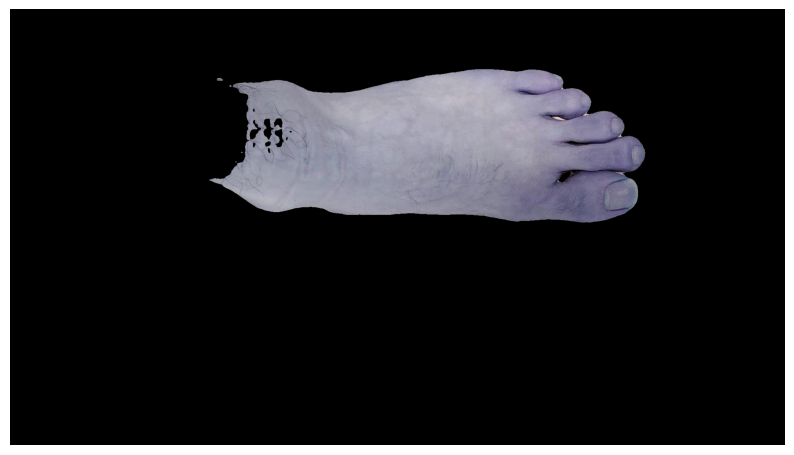

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.imshow(clean)
plt.axis("off")
plt.show()

In [29]:
os.makedirs("output", exist_ok=True)

cv2.imwrite(os.path.join("output", "output.png"), clean)

True

In [ ]:
#YOLO로 컵 bbox 검출
source_path = "태량/frame_0000.jpg"

results = model.predict(source_path, save=False, conf=0.25)


image 1/1 c:\Users\phd12\OneDrive\Desktop\Amadeus\\frame_0000.jpg: 576x1024 1 checkerboard, 1 foot, 36.8ms
Speed: 5.7ms preprocess, 36.8ms inference, 3.7ms postprocess per image at shape (1, 3, 576, 1024)


In [5]:
for result in results:
    if result.masks:
            # 첫 번째 탐지된 객체의 마스크 가져오기 (여러 개면 루프 필요)
            # data는 마스크의 픽셀 데이터 (Binary Mask)
            mask_raw = result.masks.data[0].cpu().numpy()        
            
            # 마스크 크기를 원본 이미지 크기로 리사이즈
            h, w, _ = result.orig_img.shape
            mask_resized = cv2.resize(mask_raw, (w, h))
            
            # 마스크를 Binary(0, 1)로 변환
            binary_mask = (mask_resized > 0.5).astype('uint8') * 255
            
            # 원본 이미지와 마스크 합성 (Bitwise AND)
            # 마스크 영역만 남기고 나머지는 검은색 처리
            segmented_foot = cv2.bitwise_and(result.orig_img, result.orig_img, mask=binary_mask)
            
            # 결과 저장
            cv2.imwrite('only_foot.jpg', segmented_foot)